In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [3]:
# 2つのCSVファイルを読み込み
sake_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-sake/buy_check_dummy_data.csv', encoding='utf-8')
whisky_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-whisky/buy_check_dummy_data_whisky.csv', encoding='utf-8')

# データを連結（縦方向）
data = pd.concat([sake_data, whisky_data], ignore_index=True)

# 確認
data.head()

,購入ID,商品ID,商品名,単価,数量,総価格,顧客ID,購入日時
0,1,1,獺祭２割3分,5900,2,11800,1087,2025-04-01 14:58:00
1,2,1,獺祭２割3分,5900,1,5900,1007,2025-04-01 12:43:00
2,3,1,獺祭２割3分,5900,3,17700,1062,2025-04-01 14:52:00
3,4,1,獺祭２割3分,5900,2,11800,1033,2025-04-01 18:25:00
4,5,1,獺祭２割3分,5900,3,17700,1084,2025-04-01 14:18:00


In [4]:
data.isnull().sum()

購入ID    0
商品ID    0
商品名     0
単価      0
数量      0
総価格     0
顧客ID    0
購入日時    0
dtype: int64

In [5]:
data.describe()

,購入ID,商品ID,単価,数量,総価格,顧客ID
count,9311.000000,9311.000000,9311.000000,9311.000000,9311.000000,9311.000000
mean,2413.991838,18.713457,9467.894319,1.989367,18869.920095,1049.581892
std,1482.631271,15.895143,16411.676612,0.815001,36927.020377,29.109636
min,1.000000,1.000000,1658.000000,1.000000,1658.000000,1000.000000
25%,1164.500000,3.000000,3000.000000,1.000000,6000.000000,1024.000000
50%,2328.000000,14.000000,5900.000000,2.000000,11800.000000,1049.000000
75%,3492.000000,33.000000,11900.000000,3.000000,20000.000000,1075.000000
max,5549.000000,48.000000,200000.000000,3.000000,600000.000000,1099.000000


In [6]:
# DataFrame化
columns = ['購入ID', '商品ID', '商品名', '単価', '数量', '総価格', '顧客ID', '購入日時']
df = pd.DataFrame(data, columns=columns)

# 商品名ごとに '数量' と '総価格' を合計
summary = df.groupby('商品名')[['数量', '総価格']].sum().reset_index()

# 表示
print(summary)

                            商品名    数量       総価格
0                         LINK8    80    952000
1                   あかし シングルモルト   602    998116
2                 あかし7年 シングルモルト    69   1104000
3                くら ブレンデットウイスキー   393   1572000
4   くら ラムスカスクフィニッシュ ブレンデットウイスキー   428   1926000
5         サントリーローヤル ブレンデットウイスキー   474   3318000
6                      九平次human   660   1927200
7                         九平次別誂   406   1997520
8                        九平次彼の岸   299   4461080
9                    余市　シングルモルト   533   7739160
10                   倉吉 シングルモルト   253   1518000
11            倉吉12年 ブレンデットウイスキー   240   3600000
12            倉吉18年 ブレンデットウイスキー   185   6475000
13            倉吉25年 ブレンデットウイスキー   117  11700000
14            倉吉29年 ブレンデットウイスキー   105  15750000
15            倉吉31年 ブレンデットウイスキー    37   7400000
16                          八海山   477   1049400
17                    八海山　浩和蔵仕込   171   1710000
18                      千代菊　大吟醸   401   3408500
19                      千代菊日本人形   393   

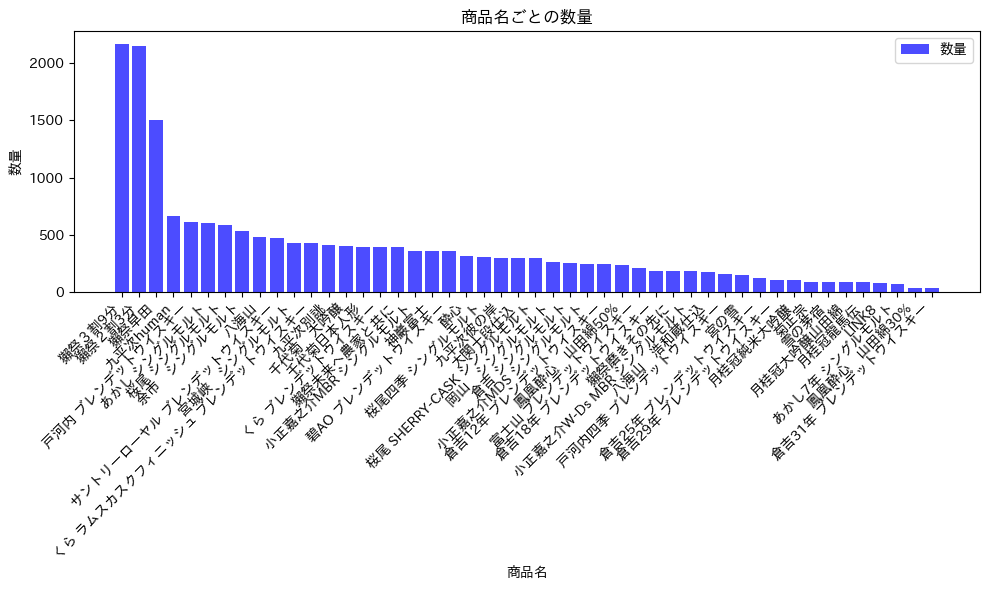

In [7]:
# 数量が多い順に並び替え
summary = summary.sort_values(by='数量', ascending=False)

# グラフ描画
plt.figure(figsize=(10, 6))
plt.bar(summary['商品名'], summary['数量'], color='blue', alpha=0.7, label='数量')
plt.xlabel('商品名')
plt.ylabel('数量')
plt.title('商品名ごとの数量')
plt.xticks(rotation=45, ha='right')  # ラベルがかぶらないように少し右寄せ
plt.legend()
plt.tight_layout()
plt.show()


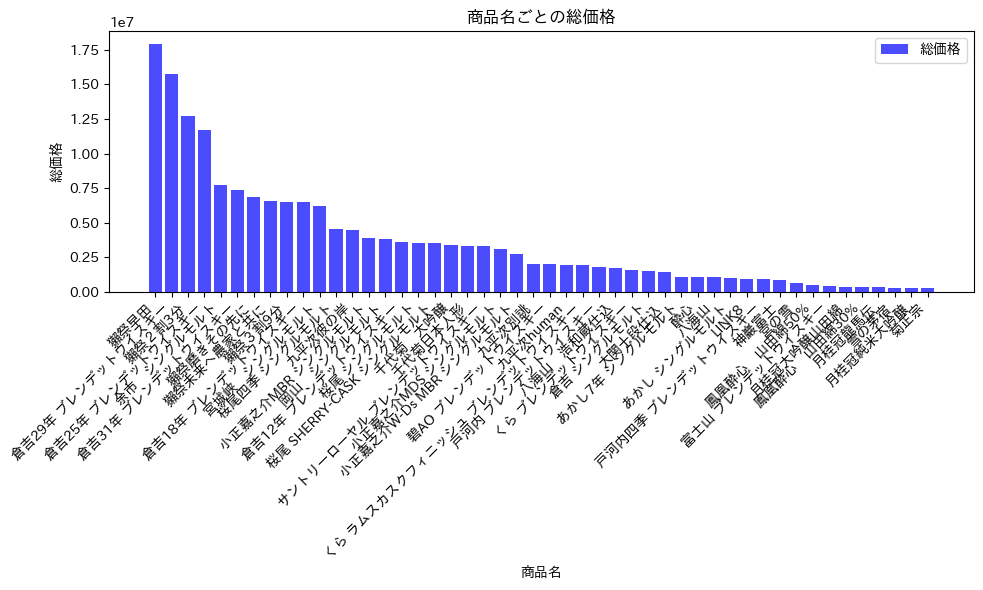

In [8]:
# 数量が多い順に並び替え
summary = summary.sort_values(by='総価格', ascending=False)

# グラフ描画
plt.figure(figsize=(10, 6))
plt.bar(summary['商品名'], summary['総価格'], color='blue', alpha=0.7, label='総価格')
plt.xlabel('商品名')
plt.ylabel('総価格')
plt.title('商品名ごとの総価格')
plt.xticks(rotation=45, ha='right')  # ラベルがかぶらないように少し右寄せ
plt.legend()
plt.tight_layout()
plt.show()


完成系のコード商品ごとの指定した変数ごとの合計をグラフ化する関数

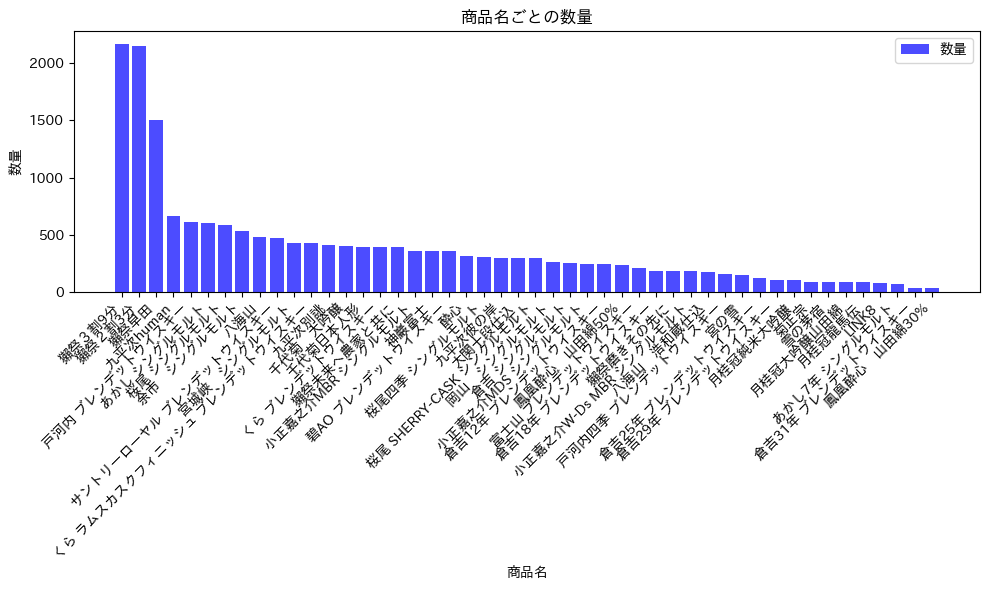

In [9]:
target_variable = '数量'

# 数量が多い順に並び替え
summary = summary.sort_values(by=target_variable, ascending=False)

# グラフ描画
plt.figure(figsize=(10, 6))
plt.bar(summary['商品名'], summary[target_variable], color='blue', alpha=0.7, label=target_variable)
plt.xlabel('商品名')
plt.ylabel(target_variable)
plt.title(f'商品名ごとの{target_variable}')  # タイトルも変数にあわせて
plt.xticks(rotation=45, ha='right')  # ラベルがかぶらないように右寄せ
plt.legend()
plt.tight_layout()
plt.show()


## 全商品の日ごとの販売数を折れ線グラフで表示させた

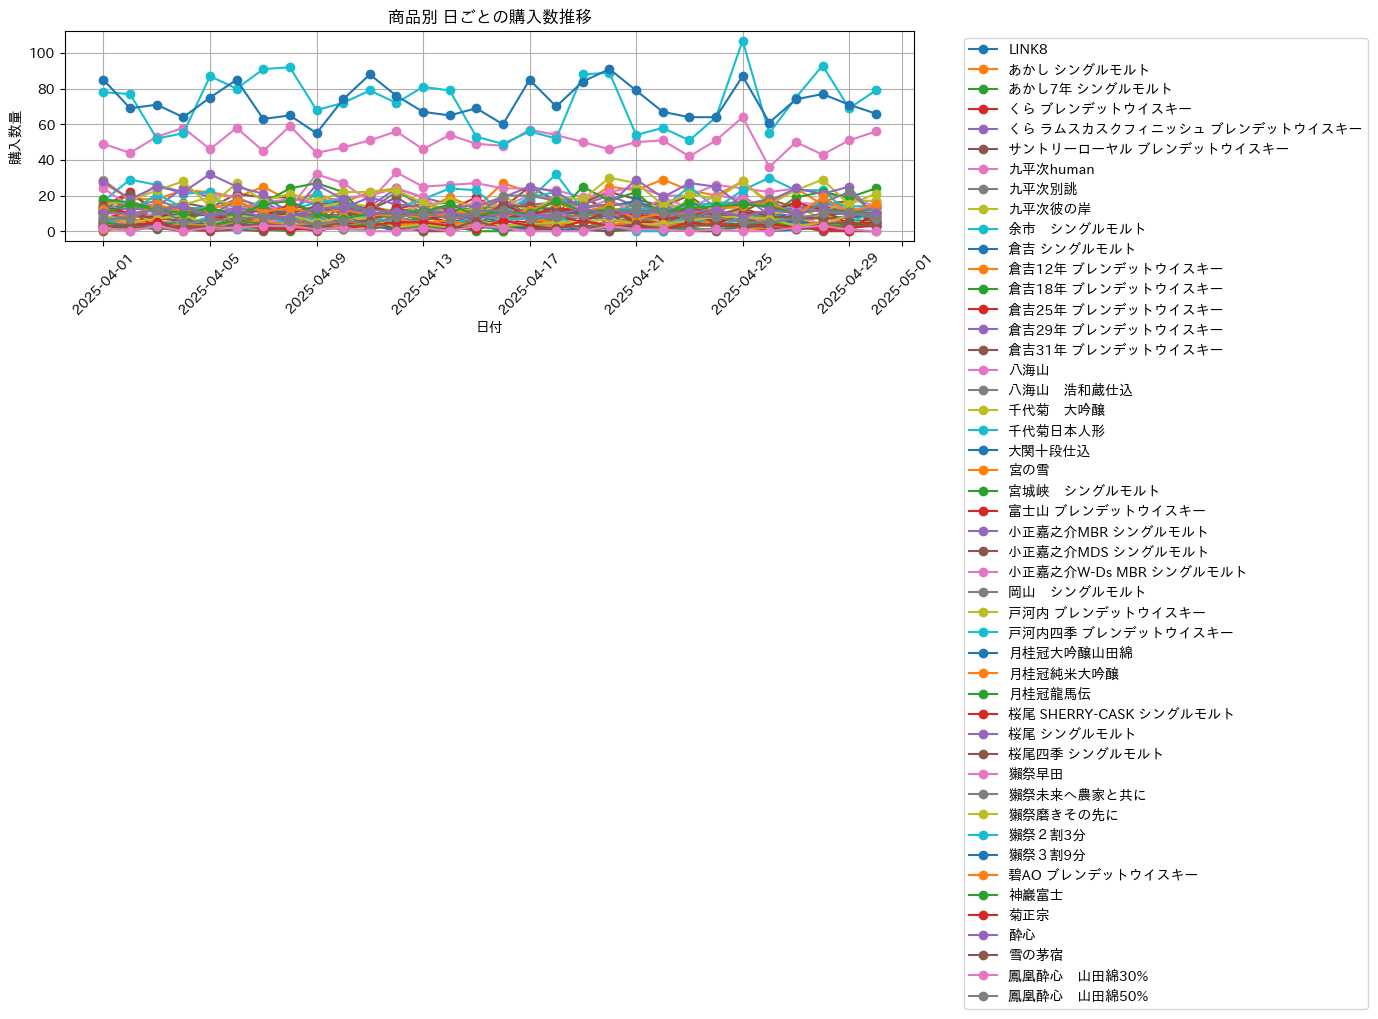

In [ ]:

columns = ['購入ID', '商品ID', '商品名', '単価', '数量', '総価格', '顧客ID', '購入日時']
df = pd.DataFrame(data, columns=columns)

# 購入日時をdatetime型に変換して、日付だけにする
df['購入日'] = pd.to_datetime(df['購入日時']).dt.date

# 商品名ごと×日ごとの数量合計を作成
pivot_table = df.pivot_table(index='購入日', columns='商品名', values='数量', aggfunc='sum', fill_value=0)
x
# グラフ化
plt.figure(figsize=(14, 7))

for product in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[product], marker='o', label=product)

plt.title('商品別 日ごとの購入数推移')
plt.xlabel('日付')
plt.ylabel('購入数量')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 凡例を外に出す
plt.grid(True)
plt.tight_layout()
plt.show()

## 単体商品を折れ線グラフ化

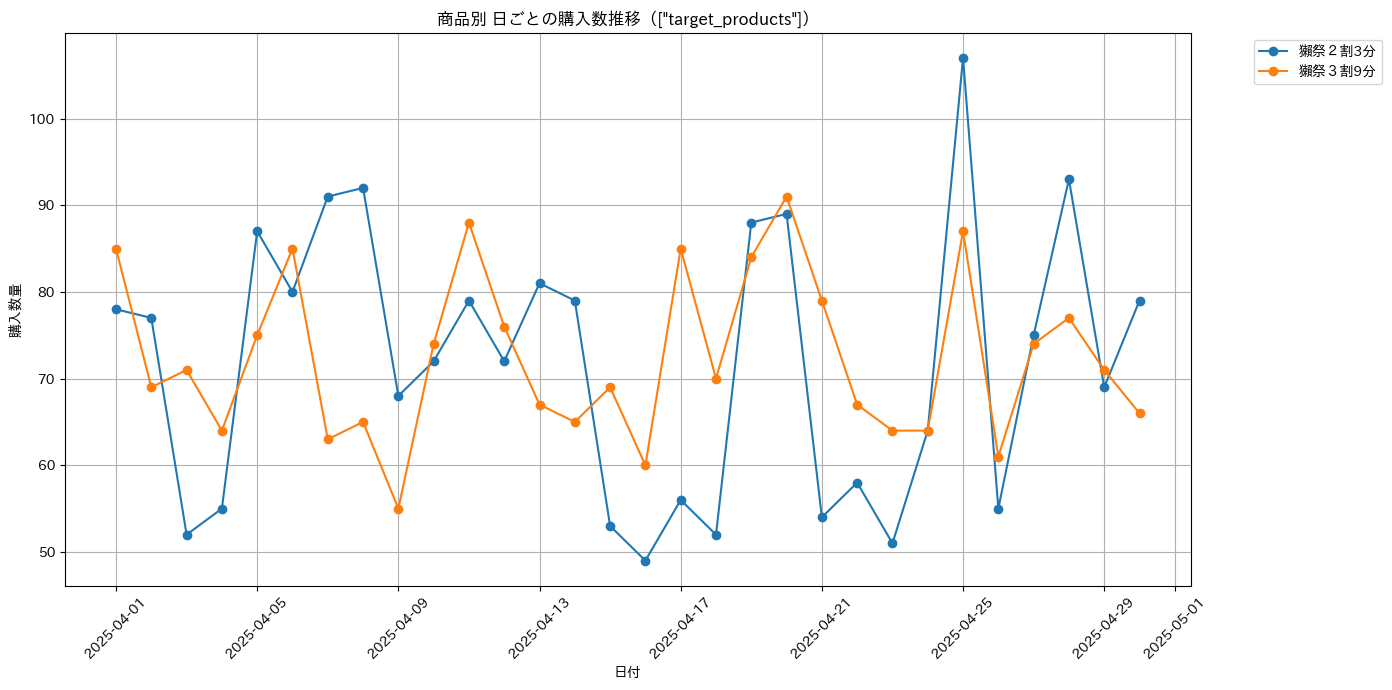

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 例: '獺祭２割3分' だけを表示したい場合
target_products = ['獺祭２割3分','獺祭３割9分']

# pivot_table の作成（ここまではそのままでOK）
pivot_table = df.pivot_table(index='購入日', columns='商品名', values='数量', aggfunc='sum', fill_value=0)

# ✅ 対象の商品名だけに絞り込み
filtered_table = pivot_table[target_products]

# グラフ化
plt.figure(figsize=(14, 7))

for product in filtered_table.columns:
    plt.plot(filtered_table.index, filtered_table[product], marker='o', label=product)

plt.title('商品別 日ごとの購入数推移（["target_products"]）')
plt.xlabel('日付')
plt.ylabel('購入数量')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## 商品名ごとの数量の累計の推移を描画

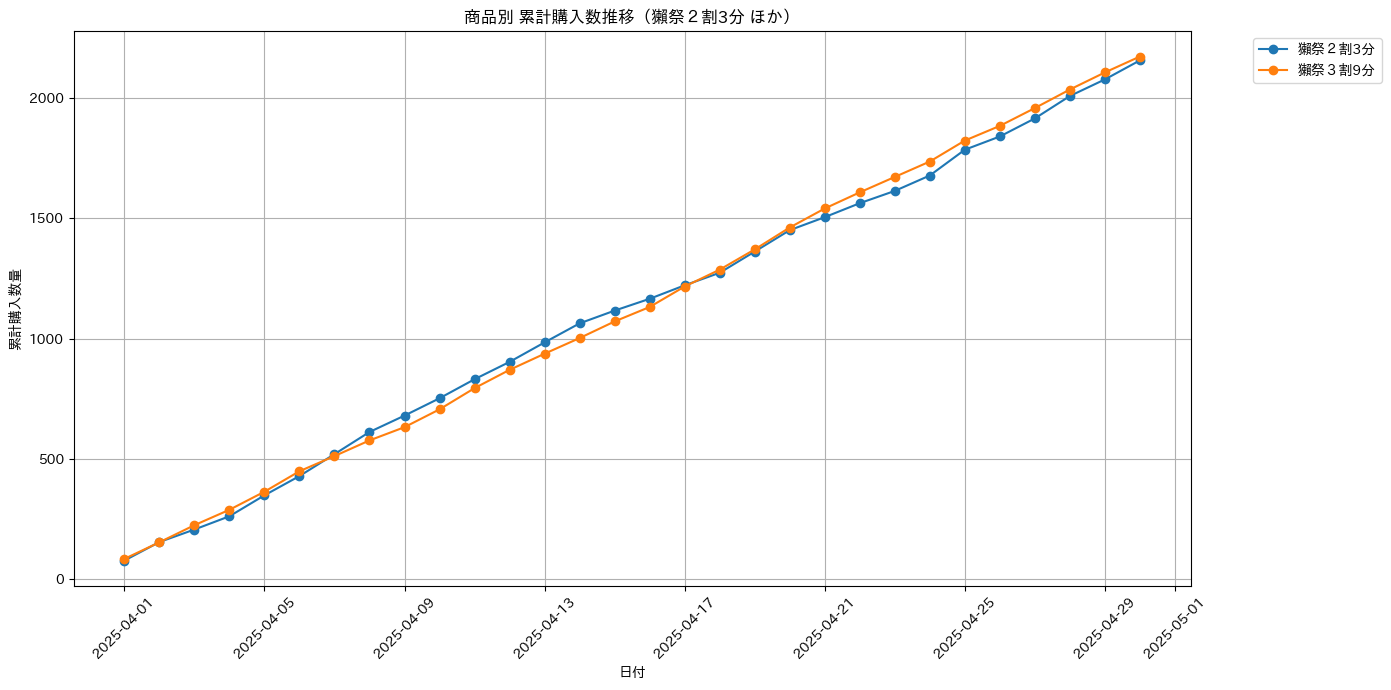

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 対象商品のリスト
target_products = ['獺祭２割3分', '獺祭３割9分']

# ピボットテーブル作成（購入日 × 商品名 → 数量）
pivot_table = df.pivot_table(index='購入日', columns='商品名', values='数量', aggfunc='sum', fill_value=0)

# 対象商品のデータだけ抽出
filtered_table = pivot_table[target_products]

# ✅ 累計本数を計算
cumulative_table = filtered_table.cumsum()

# ✅ 累計本数の推移をグラフ化
plt.figure(figsize=(14, 7))

for product in cumulative_table.columns:
    plt.plot(cumulative_table.index, cumulative_table[product], marker='o', label=product)

plt.title('商品別 累計購入数推移（獺祭２割3分 ほか）')
plt.xlabel('日付')
plt.ylabel('累計購入数量')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## 商品名ごとの日毎の売り上げの推移を描画

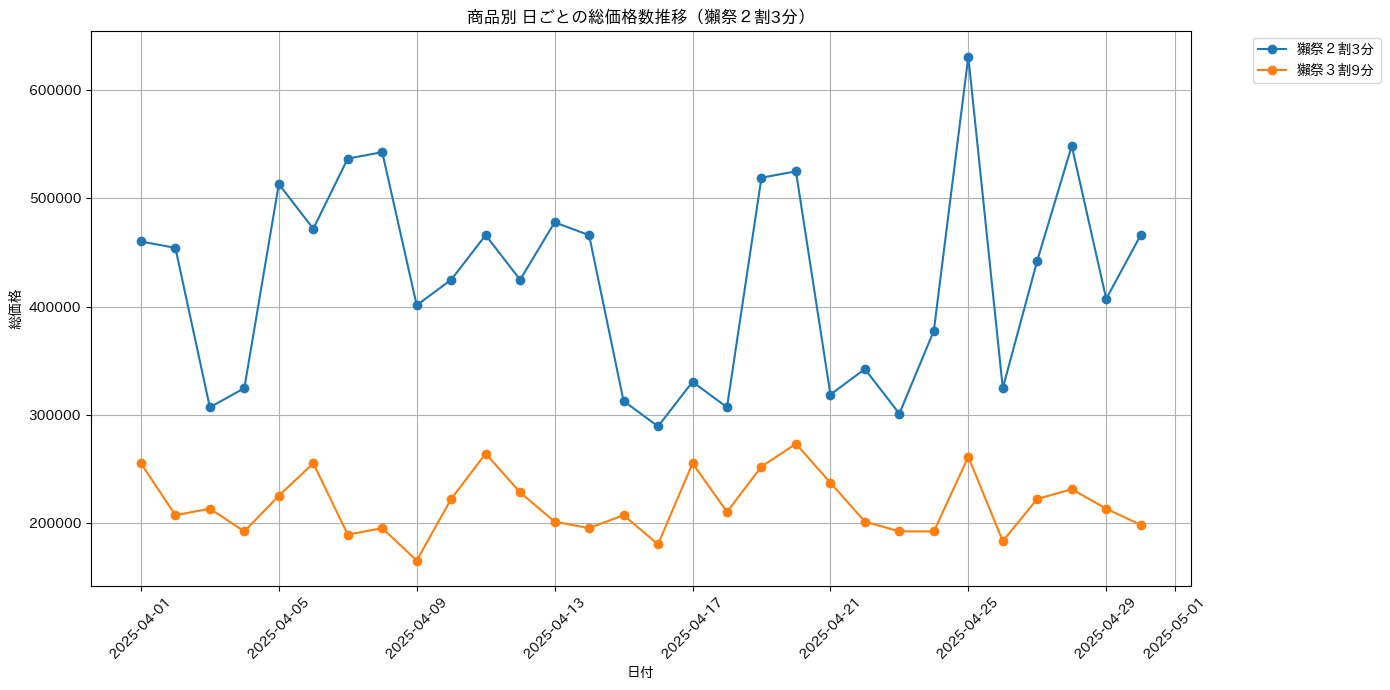

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 例: '獺祭２割3分' だけを表示したい場合
target_products = ['獺祭２割3分','獺祭３割9分']

# pivot_table の作成（ここまではそのままでOK）
pivot_table = df.pivot_table(index='購入日', columns='商品名', values='総価格', aggfunc='sum', fill_value=0)

# ✅ 対象の商品名だけに絞り込み
filtered_table = pivot_table[target_products]

# グラフ化
plt.figure(figsize=(14, 7))

for product in filtered_table.columns:
    plt.plot(filtered_table.index, filtered_table[product], marker='o', label=product)

plt.title('商品別 日ごとの総価格数推移（獺祭２割3分）')
plt.xlabel('日付')
plt.ylabel('総価格')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## 商品名ごとの売り上げの推移を描画

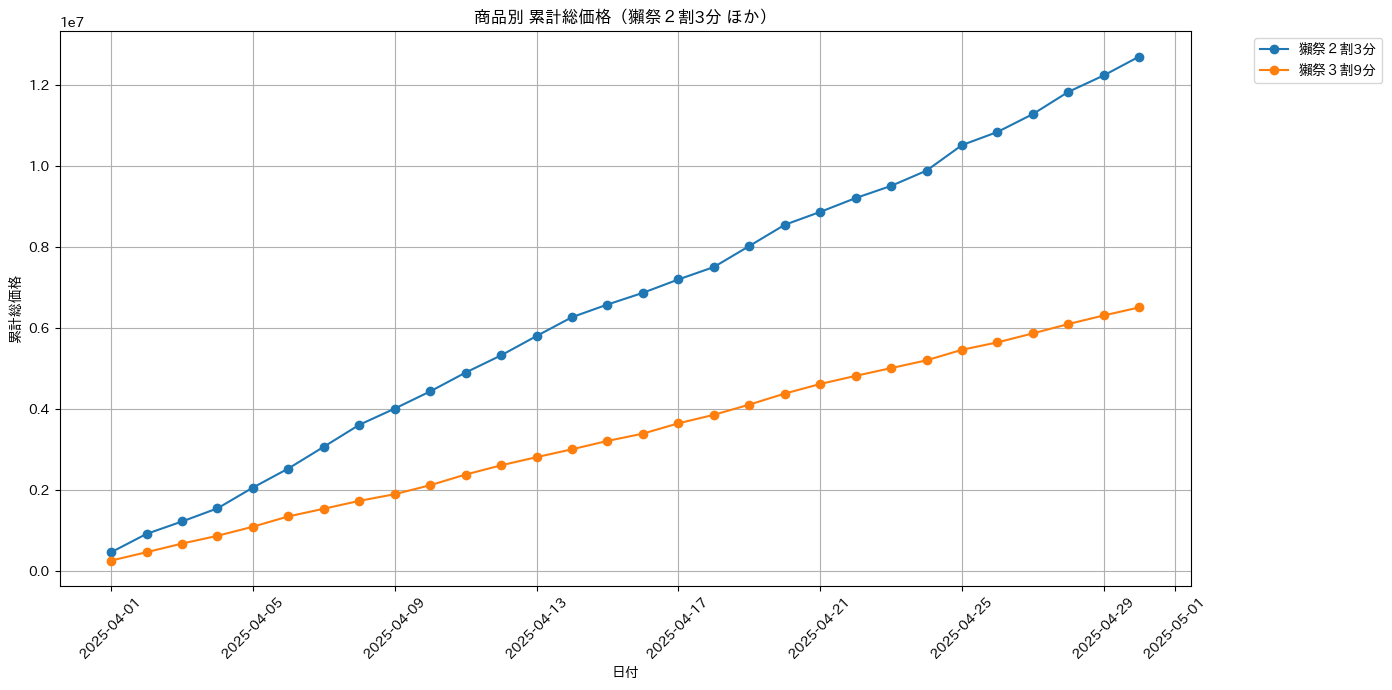

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 対象商品のリスト
target_products = ['獺祭２割3分', '獺祭３割9分']

# ピボットテーブル作成（購入日 × 商品名 → 数量）
pivot_table = df.pivot_table(index='購入日', columns='商品名', values='総価格', aggfunc='sum', fill_value=0)

# 対象商品のデータだけ抽出
filtered_table = pivot_table[target_products]

# ✅ 累計本数を計算
cumulative_table = filtered_table.cumsum()

# ✅ 累計本数の推移をグラフ化
plt.figure(figsize=(14, 7))

for product in cumulative_table.columns:
    plt.plot(cumulative_table.index, cumulative_table[product], marker='o', label=product)

plt.title('商品別 累計総価格（獺祭２割3分 ほか）')
plt.xlabel('日付')
plt.ylabel('累計総価格')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## 全商品の累計本数を計算

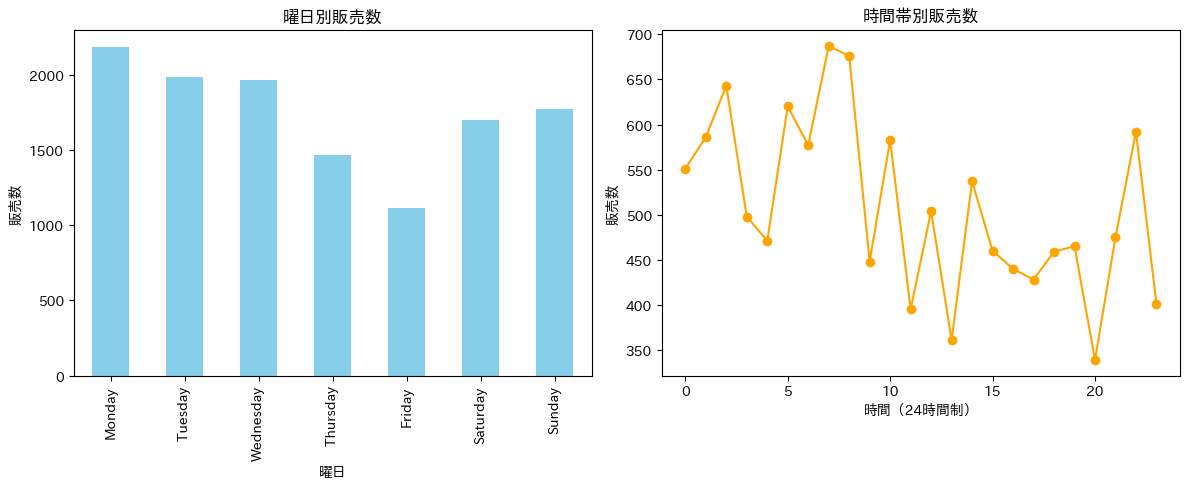

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV読み込み（ファイル名は適宜変更）
df = pd.read_csv("/Users/yugo_suzuki/mydevelopment/development/test/buy_check_data.csv", parse_dates=["購入日時"])

# 曜日・時間帯を抽出
df["曜日"] = df["購入日時"].dt.day_name()  # 曜日（英語）
df["時間"] = df["購入日時"].dt.hour        # 時間（0～23）

# --- 分析①：曜日別の総販売数（数量） ---
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = df.groupby("曜日")["数量"].sum().reindex(weekday_order)

# --- 分析②：時間帯別の総販売数 ---
hourly_sales = df.groupby("時間")["数量"].sum()

# --- 可視化 ---
plt.figure(figsize=(12, 5))

# 曜日別販売数（棒グラフ）
plt.subplot(1, 2, 1)
weekday_sales.plot(kind="bar", color="skyblue")
plt.title("曜日別販売数")
plt.xlabel("曜日")
plt.ylabel("販売数")

# 時間帯別販売数（折れ線グラフ）
plt.subplot(1, 2, 2)
hourly_sales.plot(kind="line", marker="o", color="orange")
plt.title("時間帯別販売数")
plt.xlabel("時間（24時間制）")
plt.ylabel("販売数")

plt.tight_layout()
plt.show()


## 商品の曜日ごとの販売数と時間帯ごとの販売数を可視化

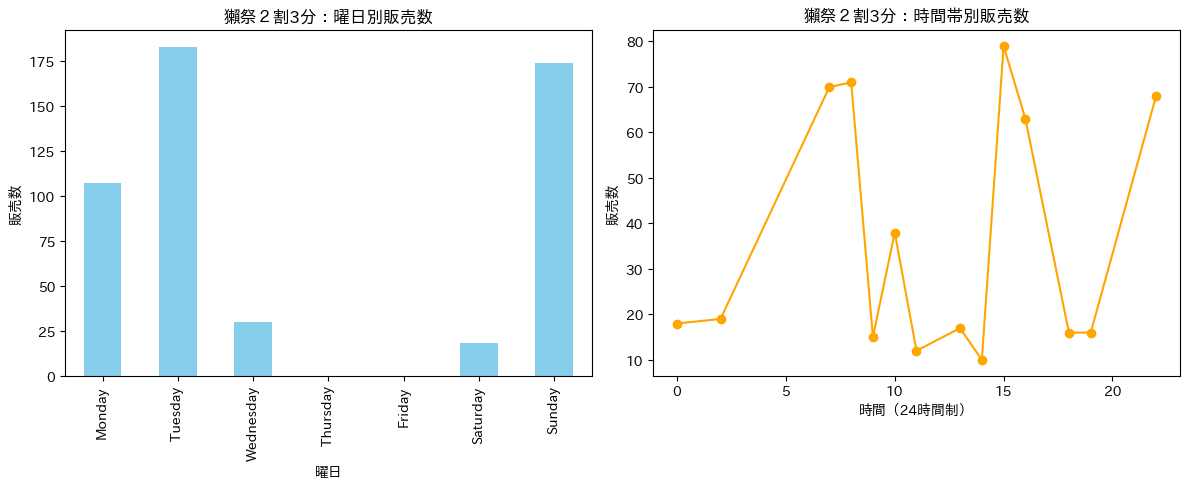

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV読み込み（ファイル名は適宜変更）
df = pd.read_csv("/Users/yugo_suzuki/mydevelopment/development/test/buy_check_data.csv", parse_dates=["購入日時"])

# ✅ 特定商品にフィルター（例：獺祭２割3分）
target_product = "獺祭２割3分"
df = df[df["商品名"] == target_product]

# 最新の購入日時から過去7日間に絞る
latest_date = df["購入日時"].max()
start_date = latest_date - pd.Timedelta(days=7)
df = df[df["購入日時"] >= start_date]


# 曜日・時間帯を抽出
df["曜日"] = df["購入日時"].dt.day_name()  # 曜日（英語）
df["時間"] = df["購入日時"].dt.hour        # 時間（0～23）

# --- 分析①：曜日別の総販売数（数量） ---
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = df.groupby("曜日")["数量"].sum().reindex(weekday_order).fillna(0)

# --- 分析②：時間帯別の総販売数 ---
hourly_sales = df.groupby("時間")["数量"].sum()

# --- 可視化 ---
plt.figure(figsize=(12, 5))

# 曜日別販売数（棒グラフ）
plt.subplot(1, 2, 1)
weekday_sales.plot(kind="bar", color="skyblue")
plt.title(f"{target_product}：曜日別販売数")
plt.xlabel("曜日")
plt.ylabel("販売数")

# 時間帯別販売数（折れ線グラフ）
plt.subplot(1, 2, 2)
hourly_sales.plot(kind="line", marker="o", color="orange")
plt.title(f"{target_product}：時間帯別販売数")
plt.xlabel("時間（24時間制）")
plt.ylabel("販売数")

plt.tight_layout()
plt.show()
